# 🌸 Aprendizaje No Supervisado con Scikit-Learn
### De datos *sin etiquetas* a patrones que sí entendemos

> **Materia:** Desarrollo de Aplicaciones para Análisis de Datos · Licenciatura en Ciencia de Datos
> **Equipo:** [Nombre 1] · [Nombre 2] · [Nombre 3]
> **Basado en:** Lección 6 — *Unsupervised Learning using Scikit-Learn* del curso
> [*Machine Learning with Python and Scikit-Learn*](https://youtu.be/hDKCxebp88A) (freeCodeCamp / Jovian).

---

### 🏷️ Cómo leer este notebook

A lo largo del notebook usamos dos etiquetas para que quede **clarísimo** qué viene del video y qué agregamos nosotros:

| Etiqueta | Significado |
|---|---|
| 🎬 **Del video** | Código o idea tal cual aparece en el notebook original de la Lección 6. |
| ✨ **Extra nuestro** | Lo que agregamos para hacerlo más claro, pedagógico e *introspectivo*. |

### 👥 Reparto de la exposición

| Bloque | Presentador | Temas |
|---|---|---|
| 🔵 **1** | Presentador 1 | Intro al no supervisado · Dataset Iris · **K-Means** |
| 🟢 **2** | Presentador 2 | **DBSCAN** · **Clustering jerárquico** (dendrograma) |
| 🟠 **3** | Presentador 3 | **PCA** · **t-SNE** · Síntesis y guía de decisión |

> ▶️ **Para correr:** ejecuta las celdas en orden (menú *Run → Run All*). El notebook está
> preparado para funcionar **sin internet** (todos los datos vienen incluidos en scikit-learn).

## 🎯 ¿Qué queremos demostrar hoy?

> **Pregunta central:** ¿puede una máquina encontrar grupos y patrones con sentido en los datos
> **sin que nadie le diga las respuestas**?

Usamos flores (Iris) y **le ocultamos la especie de cada una**. La atacamos con dos preguntas concretas
— los dos grandes usos del aprendizaje no supervisado:

| Lo que queremos saber | Cómo lo resolvemos | Bloque |
|---|---|---|
| **¿Qué grupos hay en los datos?** | *Clustering* → K-Means · DBSCAN · Jerárquico | 🔵🟢 1 y 2 |
| **¿Cómo _ver_ 4 (o 64) dimensiones a la vez?** | *Reducción de dimensión* → PCA · t-SNE | 🟠 3 |

Al final **destapamos las especies reales** y comprobamos si el modelo las redescubrió a ciegas. 🔍

---
# 🔵 BLOQUE 1 — Fundamentos + K-Means
*Presentador 1*

---

## 1. ¿Qué es el aprendizaje no supervisado?

La diferencia clave con lo que ya conoces:

| | Supervisado | **No supervisado** |
|---|---|---|
| ¿Tiene etiquetas `y`? | Sí | **No** |
| Pregunta típica | "¿Esto es spam?" | "¿Qué grupos hay aquí?" |
| Ejemplos | Regresión, clasificación | **Clustering, reducción de dimensión** |
| ¿Cómo se evalúa? | Comparando con `y` (accuracy…) | **Difícil: no hay respuesta correcta** |

> ⚠️ **Ojo con el título original.** El notebook del video se llama *"…and Recommendations"*, pero **no contiene ningún
> sistema de recomendación**: es clustering + reducción de dimensión. No prometamos recomendadores en la expo.

## 2. El dataset: Iris 🌸

Usaremos el clásico **Iris**: 150 flores, **4 medidas** (largo/ancho de sépalo y pétalo) y **3 especies**
(*setosa*, *versicolor*, *virginica*).

✨ **El truco pedagógico de todo el notebook:** Iris *sí* trae la columna `species`… pero **nunca se la daremos al modelo**.
Así, al final, podremos "hacer trampa" y comparar los grupos que el modelo encontró **a ciegas** contra las especies reales,
para ver si los *redescubrió*. Esto es raro en la vida real (casi nunca tenemos la respuesta), pero es perfecto para *entender* qué hace cada algoritmo.

In [45]:
# 🎬 Del video: librerías de visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
%matplotlib inline

# ✨ Extra (robustez): el video hace  sns.load_dataset('iris')  que DESCARGA de internet.
# Para que NUNCA falle en clase, intentamos eso y, si no hay internet, usamos la copia
# que scikit-learn trae incluida (mismos datos, mismos nombres de columna).
try:
    iris_df = sns.load_dataset('iris')                 # 🎬 como en el video
except Exception:
    from sklearn.datasets import load_iris             # ✨ plan B sin internet
    _b = load_iris(as_frame=True)
    iris_df = _b.frame.rename(columns={
        'sepal length (cm)': 'sepal_length', 'sepal width (cm)': 'sepal_width',
        'petal length (cm)': 'petal_length', 'petal width (cm)': 'petal_width'})
    iris_df['species'] = _b.target_names[_b.target.to_numpy()]
    iris_df = iris_df.drop(columns='target')

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [46]:
# ✨ Extra: confirmamos que el dataset está balanceado (50 de cada especie)
print('Forma:', iris_df.shape)
iris_df['species'].value_counts()

Forma: (150, 5)


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Exploración visual

Antes de modelar, *miremos* los datos. Graficamos dos de las cuatro medidas, coloreando por especie real.

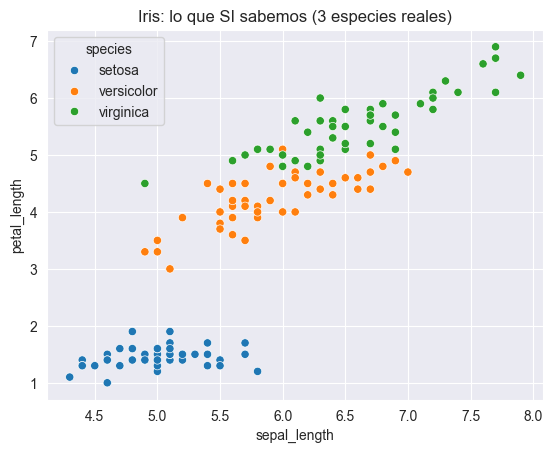

In [47]:
# 🎬 Del video
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='species')
plt.title('Iris: lo que SI sabemos (3 especies reales)')
plt.show()

**Lectura del gráfico:**

- 🟦 *setosa* está perfectamente **separada** del resto.
- 🟧🟩 *versicolor* y *virginica* se **solapan**: no hay una frontera limpia entre ellas.

✨ **Recordatorio clave:** a partir de aquí, el modelo **NO verá la columna `species`**. Tenla en mente para juzgar qué tan bien lo hace a ciegas.

## 4. Preparar los datos (`X`)

Para clustering nos quedamos **solo con las columnas numéricas** (las 4 medidas). Quitamos `species`: esa es justamente la que el modelo no debe ver.

> ✨ **Gotcha de escala (importante en general):** K-Means y PCA se basan en **distancias/varianza**, así que son
> sensibles a la **escala** de las columnas. La buena práctica es estandarizar (`StandardScaler`) antes.
> En Iris las 4 medidas ya están en centímetros comparables, así que **aquí casi no cambia** y, para respetar el video,
> trabajamos con los datos crudos. Pero en un dataset con columnas de escalas muy distintas, **olvidar esto arruina el resultado**.

In [48]:
# 🎬 Del video
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris_df[numeric_cols]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. K-Means: la intuición 🎬

> 🎯 **Problema:** partir las flores en grupos parecidos, **sin ver su especie**. Tú decides cuántos grupos (**K**).
> 🛠️ **Idea:** elegir K "centros" y mandar cada flor al más cercano, repitiendo hasta que se estabilicen.

Cada grupo tiene un **centroide** (su punto central) y cada flor pertenece al centroide más cercano.

**El algoritmo (iterativo):**

1. Coloca K centroides al azar.
2. Asigna cada punto al centroide más cercano.
3. Recalcula cada centroide como el **promedio** de sus puntos.
4. Repite 2–3 hasta que los centroides dejan de moverse.

El objetivo que minimiza es la **inercia**: la suma de distancias al cuadrado de cada punto a su centroide.

In [49]:
# 🎬 Del video
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 4)","[

### ✨ La "anatomía" de un estimador de scikit-learn

Este patrón se repite **idéntico** en los 5 algoritmos del notebook. Si lo entiendes una vez, los entiendes todos:

```python
modelo = Estimador(hiperparámetros)   # 1. configurar (ej: n_clusters=3)
modelo.fit(X)                          # 2. aprender de los datos
modelo.predict(X)   /  modelo.labels_  # 3. asignar grupo a cada punto
modelo.transform(X)                    # 4. proyectar (lo veremos en PCA/t-SNE)
```

🔍 **Introspección:** los atributos que terminan en guion bajo (`_`) son **lo que el modelo aprendió**
(no los configuraste tú): `cluster_centers_`, `inertia_`, `labels_`, `components_`, `explained_variance_ratio_`…
Iremos inspeccionándolos uno por uno.

In [50]:
# 🎬 Del video: los centroides aprendidos (uno por cluster, con las 4 medidas)
print('Centroides aprendidos (model.cluster_centers_):')
print(model.cluster_centers_.round(2))

# 🎬 Del video: predecir el cluster de cada flor
preds = model.predict(X)
preds

Centroides aprendidos (model.cluster_centers_):
[[6.85 3.08 5.72 2.05]
 [5.01 3.43 1.46 0.25]
 [5.88 2.74 4.39 1.43]]


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

**Desglose:**

- `cluster_centers_` → 3 filas (un centroide por cluster) × 4 columnas (las 4 medidas). Es el "perfil promedio" de cada grupo.
- `preds` → a qué cluster (0, 1 o 2) fue asignada cada flor.

> 🔢 **Los números de cluster son arbitrarios.** "Cluster 0" no significa nada por sí mismo; podría haberse llamado "2".
> Solo importa *qué puntos quedaron juntos*, no la etiqueta numérica.

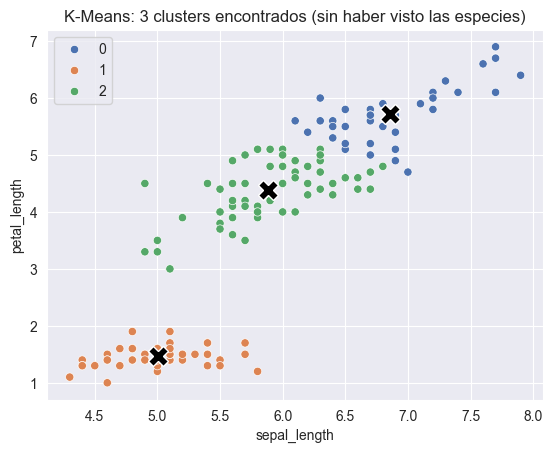

In [51]:
# 🎬 Del video: graficamos los clusters encontrados + los centroides
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds, palette='deep')
centers_x, centers_y = model.cluster_centers_[:, 0], model.cluster_centers_[:, 2]
plt.plot(centers_x, centers_y, 'X', color='black', markersize=14, markeredgecolor='white')
plt.title('K-Means: 3 clusters encontrados (sin haber visto las especies)')
plt.show()

**Desglose — un detalle fácil de pasar por alto:**

```python
centers_x, centers_y = model.cluster_centers_[:, 0], model.cluster_centers_[:, 2]
```

Los ejes del gráfico son `sepal_length` y `petal_length`. En `numeric_cols` esas son la **columna 0** y la **columna 2**
(`['sepal_length'=0, 'sepal_width'=1, 'petal_length'=2, 'petal_width'=3]`). Por eso tomamos `[:, 0]` y `[:, 2]`:
para que las "X" de los centroides caigan en los **mismos ejes** que los puntos. ✨ (El video lo hace sin explicarlo.)

In [52]:
# ✨ Extra: como Iris SI tiene etiquetas, "hacemos trampa" y comparamos
# los clusters (a ciegas) contra las especies reales.
pd.crosstab(iris_df['species'], preds, rownames=['Especie real'], colnames=['Cluster'])

Cluster,0,1,2
Especie real,,,
setosa,0,50,0
versicolor,3,0,47
virginica,36,0,14


**Desglose — el momento "ajá":**

Cada fila es una especie real; cada columna, un cluster que K-Means encontró **sin verlas**. Si lees la tabla:

- 🟦 *setosa* cae **completa** en un solo cluster → la separó perfecto.
- 🟧🟩 *versicolor* y *virginica* se **reparten** entre dos clusters → como se solapaban, el modelo confunde algunas.

✨ **Lección:** sin etiquetas, K-Means *redescubrió* en gran parte las especies. No es magia: aprovechó que están separadas en el espacio.

## 6. ¿Qué tan bueno es el agrupamiento? La inercia 🎬

`inertia_` = suma de distancias al cuadrado de cada punto a su centroide. **Menor inercia = clusters más compactos.**

In [53]:
# 🎬 Del video
print('Inercia con k=3:', round(model.inertia_, 2))

Inercia con k=3: 78.86


### ⚠️ La trampa de "minimizar la inercia"

La inercia **siempre baja** si subimos K (con K = 150, cada flor sería su propio cluster e inercia = 0).
Así que **no podemos simplemente minimizarla**. Veámoslo: pidamos 6 clusters cuando sabemos que hay 3 especies.

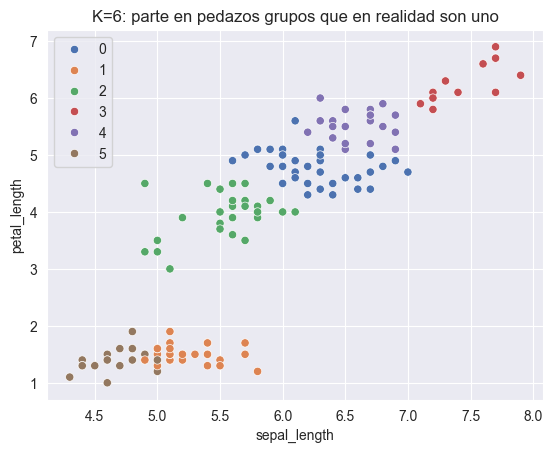

Inercia con k=6: 39.07 (menor que con k=3, pero NO es mejor)


In [54]:
# 🎬 Del video: pedir más clusters de los que "tienen sentido"
model6 = KMeans(n_clusters=6, random_state=42).fit(X)
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=model6.predict(X), palette='deep')
plt.title('K=6: parte en pedazos grupos que en realidad son uno')
plt.show()
print('Inercia con k=6:', round(model6.inertia_, 2), '(menor que con k=3, pero NO es mejor)')

## 7. Elegir K: el método del codo + la silueta

🎬 **Método del codo (video):** graficamos inercia vs K y buscamos el "codo", el punto donde bajar más K ya casi no ayuda.

✨ **Extra — silueta:** agregamos el *silhouette score* (de −1 a 1): mide qué tan bien separado está cada punto de los
otros clusters. A diferencia de la inercia, **no premia automáticamente tener más clusters**, así que da una segunda opinión.

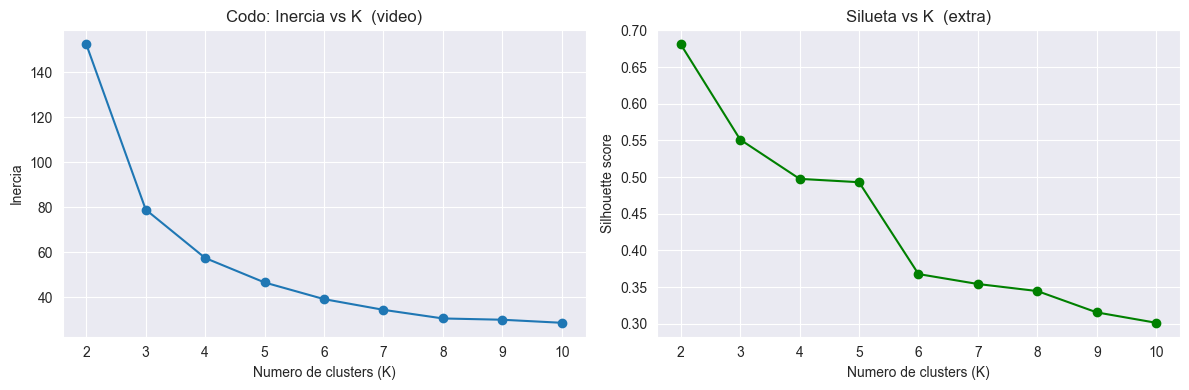

In [55]:
# 🎬 codo  +  ✨ silueta
from sklearn.metrics import silhouette_score

options = range(2, 11)
inertias, silhouettes = [], []
for k in options:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))   # ✨ extra

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(options, inertias, '-o')
ax1.set(title='Codo: Inercia vs K  (video)', xlabel='Numero de clusters (K)', ylabel='Inercia')
ax2.plot(options, silhouettes, '-o', color='green')
ax2.set(title='Silueta vs K  (extra)', xlabel='Numero de clusters (K)', ylabel='Silhouette score')
plt.tight_layout(); plt.show()

**Desglose — y aquí pasa algo interesante:**

- 📉 El **codo** se ve alrededor de **K=3**: coincide con nuestras 3 especies.
- 📈 La **silueta** suele ser más alta en **K=2**. ¿Por qué? Porque *setosa* está clarísimamente separada,
  pero *versicolor* y *virginica* se solapan tanto que, "matemáticamente", **se ven como un solo grupo**.

✨ **Lección profunda:** el no supervisado descubre la estructura que *hay en los datos*, no necesariamente la que
*tú esperabas*. Dos métricas razonables pueden sugerir K distintos. **No hay una única respuesta correcta** — por eso evaluar clustering es difícil.

## 8. Gotchas y cheatsheet de K-Means

**⚠️ Gotchas (cuándo falla / qué cuidar):**

1. **Tienes que elegir K** de antemano (usa codo + silueta + conocimiento del dominio).
2. **Asume clusters "redondos" y de tamaño similar.** Con formas alargadas o densidades distintas, falla feo *(lo vemos en el Bloque 2)*.
3. **Sensible a la escala** de las columnas → estandariza cuando haga falta.
4. **Empieza al azar** → fija `random_state` para resultados reproducibles. *(🎬 el video menciona Mini-Batch K-Means para datasets enormes.)*

**📝 Cheatsheet:**

- `KMeans(n_clusters=K, random_state=42)` → `.fit(X)` → `.predict(X)` / `.labels_`.
- `.cluster_centers_` = centroides aprendidos · `.inertia_` = qué tan compactos.
- Elegir K: **codo** (inercia) + **silueta**.

> ✅ **Qué demostramos:** K-Means agrupó las flores **a ciegas** y redescubrió *setosa* perfecta (*versicolor*/*virginica* se confunden por solaparse). El **codo + silueta** ayudan a elegir K — aunque aquí ni siquiera coinciden entre sí.

---

> 🔵➡️🟢 **Puente al Bloque 2:** K-Means asume grupos redondos. ¿Y si los grupos tienen forma de luna, o hay ruido?
> El Bloque 2 abre justo con un caso donde K-Means **se rompe**.

---
# 🟢 BLOQUE 2 — Más allá de K-Means: DBSCAN y Jerárquico
*Presentador 2*

---

## 9. ✨ Demo: cuando K-Means se rompe

Generamos datos con forma de **dos lunas** entrelazadas (`make_moons`). Para el ojo humano son **dos grupos** obvios.
Veamos qué hace K-Means… y qué hace DBSCAN (el algoritmo que presentamos enseguida).

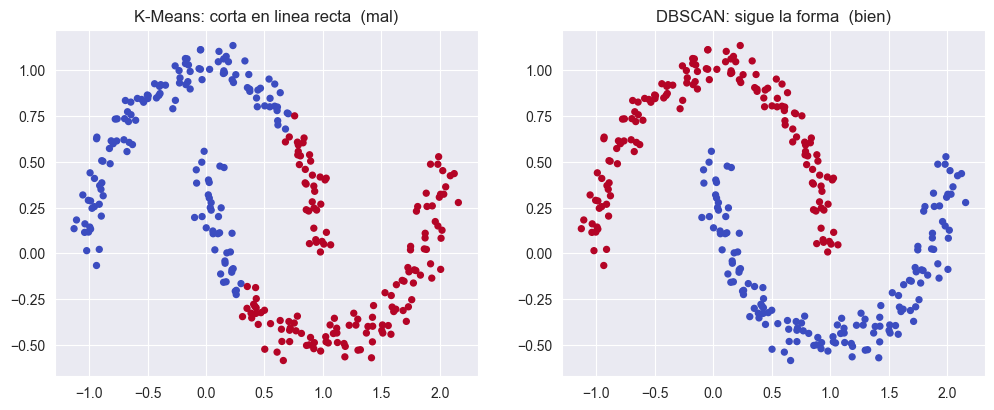

In [56]:
# ✨ Extra (NO está en el video): el ejemplo clásico que motiva DBSCAN.
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN

X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=42)
km_moons = KMeans(n_clusters=2, random_state=42).fit_predict(X_moons)
db_moons = DBSCAN(eps=0.25, min_samples=5).fit_predict(X_moons)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons, cmap='coolwarm', s=18)
a1.set_title('K-Means: corta en linea recta  (mal)')
a2.scatter(X_moons[:, 0], X_moons[:, 1], c=db_moons, cmap='coolwarm', s=18)
a2.set_title('DBSCAN: sigue la forma  (bien)')
plt.show()

**Desglose:** K-Means solo sabe trazar fronteras alrededor de centroides → parte las lunas por la mitad.
DBSCAN agrupa por **densidad** (puntos pegados entre sí), así que **sigue la forma** sin importar que sea curva.
Esa es exactamente la limitación que K-Means tiene y DBSCAN resuelve.

## 10. DBSCAN: la intuición 🎬

> 🎯 **Problema:** agrupar cuando **no sabemos cuántos grupos hay** y/o las formas son raras (recuerda las lunas).
> 🛠️ **Idea:** formar grupos donde los puntos están **densamente juntos**; lo que queda aislado es **ruido**.

**DBSCAN** = *Density-Based Spatial Clustering of Applications with Noise*. Agrupa por **densidad** y tiene 2 parámetros:

- `eps` (ε): radio para considerar a dos puntos "vecinos".
- `min_samples`: cuántos vecinos necesita un punto para ser **núcleo** (centro de un cluster denso).

Clasifica cada punto como: **núcleo** (zona densa), **borde** (cerca de un núcleo) o **ruido/outlier** (aislado → etiqueta `-1`).

✨ **Dos ventajas grandes sobre K-Means:** (1) **no le dices cuántos clusters** hay — los descubre; (2) **detecta outliers** automáticamente.

In [57]:
# 🎬 Del video
model = DBSCAN(eps=1.1, min_samples=4)
model.fit(X)
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

**Desglose:** fíjate que **no hay `predict`** — DBSCAN asigna las etiquetas directamente en `labels_`. La etiqueta **`-1` = ruido** (puntos que no entraron en ningún cluster denso).

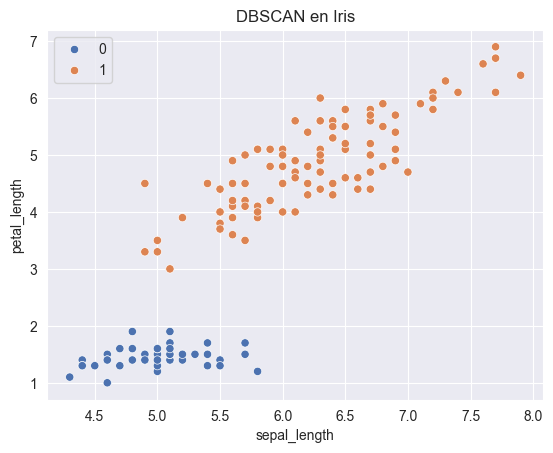

Clusters encontrados: [0 1] | puntos de ruido (-1): 0


In [58]:
# 🎬 Del video  (+ ✨ reporte dinámico de clusters y ruido)
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=model.labels_, palette='deep')
plt.title('DBSCAN en Iris')
plt.show()
print('Clusters encontrados:', np.unique(model.labels_),
      '| puntos de ruido (-1):', int((model.labels_ == -1).sum()))

**Desglose + ⚠️ gotcha:** en Iris, con `eps=1.1, min_samples=4`, DBSCAN encuentra **2 clusters y _ningún_ punto de ruido**:
aísla *setosa* perfecta en un grupo y mete *versicolor* + *virginica* en **una sola región densa** (el otro). El `-1` (ruido)
no apareció con estos parámetros, pero surge en cuanto bajas `eps` o subes `min_samples`.

✨ **DBSCAN no es "mejor" que K-Means — es distinto.** Aquí ni siquiera intenta separar *versicolor* de *virginica* (las ve
como una sola masa densa), mientras K-Means sí las dividió (con algunos errores). En cambio, en las **lunas** DBSCAN brilló y
K-Means fracasó. El parámetro `eps` es **muy sensible**: cámbialo un poco y todo cambia — elegir bien `eps` es el arte de DBSCAN.

> ✅ **Qué demostramos:** agrupando **por densidad**, DBSCAN resolvió las **lunas** que K-Means no pudo, y en Iris aisló *setosa* **sin que le dijéramos cuántos grupos había**.

## 11. Clustering jerárquico: la intuición

> 🎯 **Problema:** ¿y si quiero ver **todos los niveles** de agrupamiento y **decidir el número de grupos después**?
> 🛠️ **Idea:** ir fusionando los dos grupos más cercanos hasta tener uno, y dibujar el árbol resultante (*dendrograma*).

> ✨ **Nota:** el video **deja esto como ejercicio sin resolver**. Aquí lo implementamos completo.

El clustering **jerárquico (aglomerativo)** construye un **árbol** de clusters:

1. Cada punto empieza como su propio cluster.
2. Se fusionan los **dos clusters más cercanos**.
3. Se repite hasta que queda **un solo** cluster que contiene todo.

La gran ventaja: produce un **dendrograma** (un árbol) que puedes "cortar" a la altura que quieras → **eliges K *después*, viéndolo**, no antes.

In [59]:
# ✨ Extra: resolvemos el ejercicio del video con AgglomerativeClustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(X)
pd.crosstab(iris_df['species'], hc_labels, rownames=['Especie real'], colnames=['Cluster jerarquico'])

Cluster jerarquico,0,1,2
Especie real,,,
setosa,0,50,0
versicolor,49,0,1
virginica,15,0,35


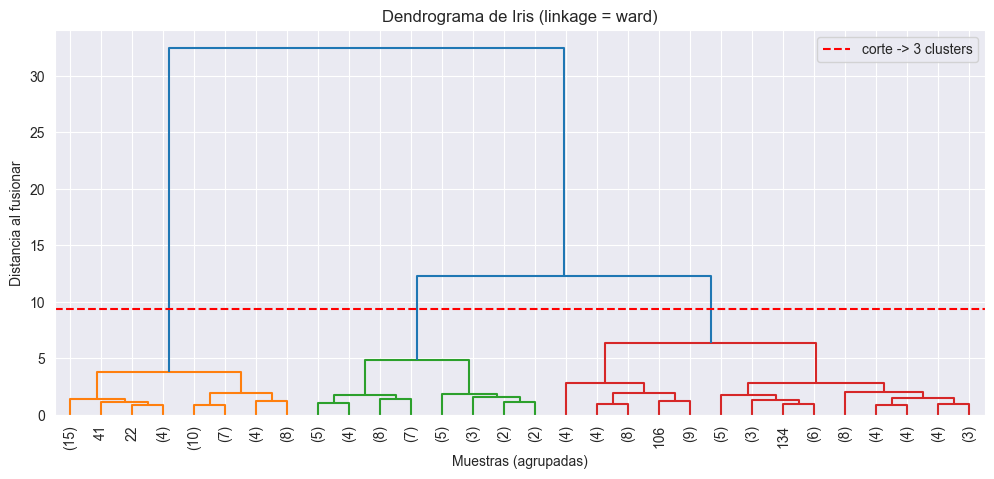

In [60]:
# ✨ Extra: el dendrograma, la visual estrella del jerárquico (con scipy)
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')                 # ward = minimiza la varianza al fusionar
thr = (Z[-3, 2] + Z[-2, 2]) / 2               # altura de corte que deja 3 grupos

plt.figure(figsize=(12, 5))
dendrogram(Z, color_threshold=thr, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.axhline(thr, color='red', ls='--', label='corte -> 3 clusters')
plt.title('Dendrograma de Iris (linkage = ward)')
plt.xlabel('Muestras (agrupadas)'); plt.ylabel('Distancia al fusionar')
plt.legend(); plt.show()

**Cómo leer el dendrograma:**

- El eje **vertical** es la distancia a la que dos grupos se fusionan: fusiones **bajas** = grupos muy parecidos; **altas** = grupos diferentes.
- Si trazas una línea horizontal (la **roja**) y cuentas cuántas ramas verticales corta, ese es tu **número de clusters**.
- ✨ Por eso no necesitas fijar K de antemano: **cortas el árbol donde tenga sentido** mirando los "saltos" grandes de distancia.

> ✅ **Qué demostramos:** el **dendrograma** mostró toda la jerarquía y nos dejó **elegir el número de grupos _después_**, cortando el árbol a la altura que tiene sentido.

## 12. Comparativa de los 3 métodos de clustering

| | **K-Means** | **DBSCAN** | **Jerárquico** |
|---|---|---|---|
| ¿Hay que elegir K? | **Sí**, de antemano | **No** | No (cortas el árbol después) |
| Formas que maneja | Redondas, tamaño similar | **Cualquiera** (densidad) | Cualquiera |
| ¿Detecta outliers? | No | **Sí** (`-1`) | No |
| Sensible a escala | Sí | Sí (`eps`) | Sí |
| Da una visual extra | Centroides | — | **Dendrograma** |
| Bueno cuando… | Grupos compactos y sabes K | Formas raras + ruido | Quieres ver la jerarquía |

---

> 🟢➡️🟠 **Puente al Bloque 3:** todo esto lo graficamos usando **2 de las 4 columnas**. Pero Iris tiene 4 dimensiones,
> y hay datos con **cientos**. ¿Cómo *vemos* todas las dimensiones a la vez? Para eso existe la **reducción de dimensionalidad**.

---
# 🟠 BLOQUE 3 — Reducción de dimensionalidad: PCA y t-SNE
*Presentador 3*

---

## 13. El problema que resuelve este bloque

> 🎯 **Problema:** llevamos todo el notebook graficando **2 de las 4 columnas** — ignorando información. Y no se puede dibujar en 4D (ni en 64D).
> 🛠️ **Idea:** comprimir muchas columnas en **2** que sí podamos graficar, **perdiendo lo menos posible**.

Esto se llama **reducción de dimensionalidad** y sirve para:

- 👁️ **Visualizar** datos de alta dimensión en 2D/3D.
- ⚡ **Acelerar** modelos (menos columnas = menos cómputo).
- 🗜️ **Comprimir** sin perder lo esencial.

## 14. PCA: la intuición 🎬

> 🎯 **Problema:** resumir 4 (o 64) columnas en **2**, conservando la mayor **información** posible.
> 🛠️ **Idea:** inventar 2 ejes nuevos orientados hacia donde los datos **más varían**.

**PCA** (*Principal Component Analysis*) busca esos ejes (las *componentes principales*): **combinaciones lineales** de las
columnas originales, ordenadas de mayor a menor **varianza**. Nos quedamos con las 2 primeras → de 4D a 2D.

In [61]:
# 🎬 Del video
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
transformed = pca.fit_transform(iris_df[numeric_cols])   # fit + transform en un paso
transformed[:5]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451]])

**Desglose:** aparece el cuarto verbo del API: **`transform`** (proyectar). `fit_transform` = `fit` (aprende los ejes) + `transform` (proyecta los datos a esos ejes). El resultado tiene **2 columnas** en vez de 4.

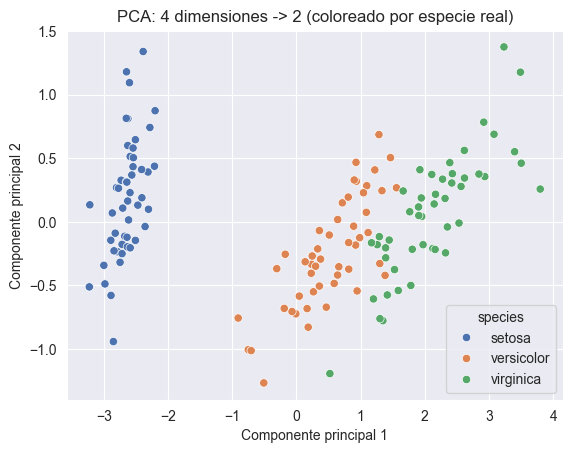

In [62]:
# 🎬 Del video
sns.scatterplot(x=transformed[:, 0], y=transformed[:, 1], hue=iris_df['species'], palette='deep')
plt.title('PCA: 4 dimensiones -> 2 (coloreado por especie real)')
plt.xlabel('Componente principal 1'); plt.ylabel('Componente principal 2')
plt.show()

**Desglose:** ¡Las 3 especies quedan **muy bien separadas usando solo 2 ejes**! Importante: estos ejes **ya no son medidas reales**
(no son "cm de pétalo"), son combinaciones de las 4 medidas que capturan la mayor variación.

Varianza explicada por componente: [0.925 0.053 0.017 0.005]
Acumulada: [0.925 0.978 0.995 1.   ]


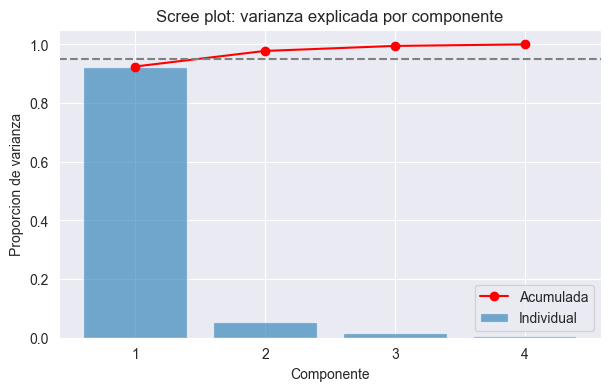

In [63]:
# ✨ Extra: ¿cuánta información conservamos? El video NUNCA lo muestra.
pca_full = PCA().fit(iris_df[numeric_cols])
ratios = pca_full.explained_variance_ratio_
print('Varianza explicada por componente:', ratios.round(3))
print('Acumulada:', ratios.cumsum().round(3))

plt.figure(figsize=(7, 4))
comps = range(1, len(ratios) + 1)
plt.bar(comps, ratios, alpha=0.6, label='Individual')
plt.plot(comps, ratios.cumsum(), '-o', color='red', label='Acumulada')
plt.axhline(0.95, ls='--', color='gray')
plt.title('Scree plot: varianza explicada por componente')
plt.xlabel('Componente'); plt.ylabel('Proporcion de varianza'); plt.xticks(list(comps))
plt.legend(); plt.show()

**Desglose — `explained_variance_ratio_` (puro oro y el video lo omite):**

Nos dice qué fracción de la **información total** captura cada componente. La suma acumulada de las **2 primeras** suele dar
**~0.98** en Iris → por eso el gráfico 2D de arriba funcionaba tan bien: **casi no perdimos nada** al pasar de 4D a 2D.

> ⚠️ **Gotchas de PCA:** (1) es **lineal** — solo encuentra ejes rectos; (2) es **sensible a la escala** (estandariza si las
> columnas tienen unidades distintas); (3) los componentes son **combinaciones**, así que se vuelven menos interpretables que las columnas originales.

> ✅ **Qué demostramos:** PCA comprimió **4D → 2D conservando ~98%** de la información y separó las 3 especies usando solo 2 ejes nuevos.

## 15. t-SNE: la intuición 🎬

> 🎯 **Problema:** PCA solo hace ejes **rectos**; ¿y si la estructura es curva/compleja y solo queremos **verla**?
> 🛠️ **Idea:** colocar los puntos en 2D cuidando que los **vecinos cercanos** sigan cerca (aunque deforme lo demás).

**t-SNE** (*t-distributed Stochastic Neighbor Embedding*) es reducción de dimensión **no lineal**, pensada **solo para visualizar**.
Es excelente revelando *agrupamientos* en datos de muchas dimensiones.

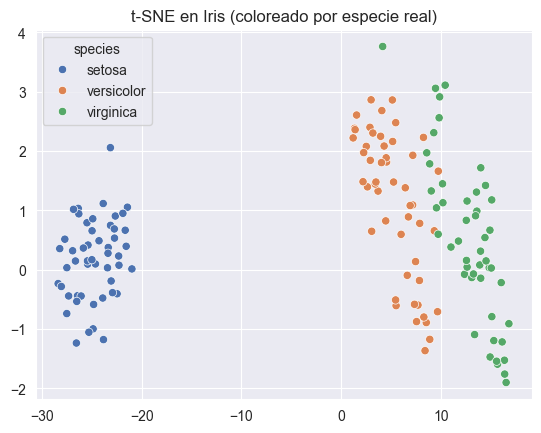

In [64]:
# 🎬 Del video  +  ✨ random_state (el video NO lo fija -> resultado distinto cada vez)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)          # ✨ reproducible
tsne_iris = tsne.fit_transform(iris_df[numeric_cols].values)
sns.scatterplot(x=tsne_iris[:, 0], y=tsne_iris[:, 1], hue=iris_df['species'], palette='deep')
plt.title('t-SNE en Iris (coloreado por especie real)')
plt.show()

**Desglose + ⚠️ gotchas de t-SNE (clave para no engañarte):**

- 🎲 **Es estocástico:** corre dos veces y obtienes mapas distintos. Por eso fijamos `random_state` (✨ el video no lo hace).
- 📏 **Las distancias entre clusters NO significan nada.** Que dos grupos salgan lejos en t-SNE no implica que sean "más diferentes". Solo confía en *quién está agrupado con quién*.
- 🎛️ Tiene un parámetro `perplexity` (≈ cuántos vecinos considerar) que cambia el resultado.
- 🚫 **No tiene `transform`** para datos nuevos (a diferencia de PCA). Es **solo para visualizar lo que ya tienes**.

## 16. ✨ ¿Para qué t-SNE si PCA ya separó Iris?

Buena pregunta — y la respuesta es **introspectiva**: en Iris (solo 4D) **ambos se ven casi igual** porque hay muy pocas dimensiones.
La diferencia se nota con datos **de verdad** de alta dimensión. Probemos con **dígitos escritos a mano**: imágenes de 8×8 píxeles = **64 dimensiones**.

Forma: (1797, 64) -> cada imagen es un punto en 64 dimensiones


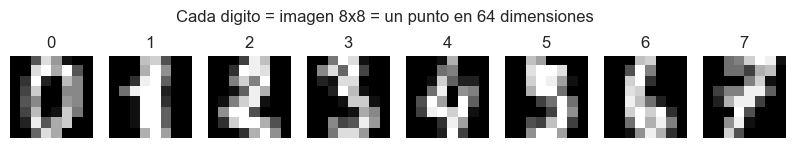

In [65]:
# ✨ Extra: dataset 'digits', 64 dimensiones, también incluido en scikit-learn (offline)
from sklearn.datasets import load_digits

digits = load_digits()
print('Forma:', digits.data.shape, '-> cada imagen es un punto en 64 dimensiones')

fig, axes = plt.subplots(1, 8, figsize=(10, 1.8))
for ax, img, lab in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap='gray'); ax.set_title(str(lab)); ax.axis('off')
plt.suptitle('Cada digito = imagen 8x8 = un punto en 64 dimensiones')
plt.show()

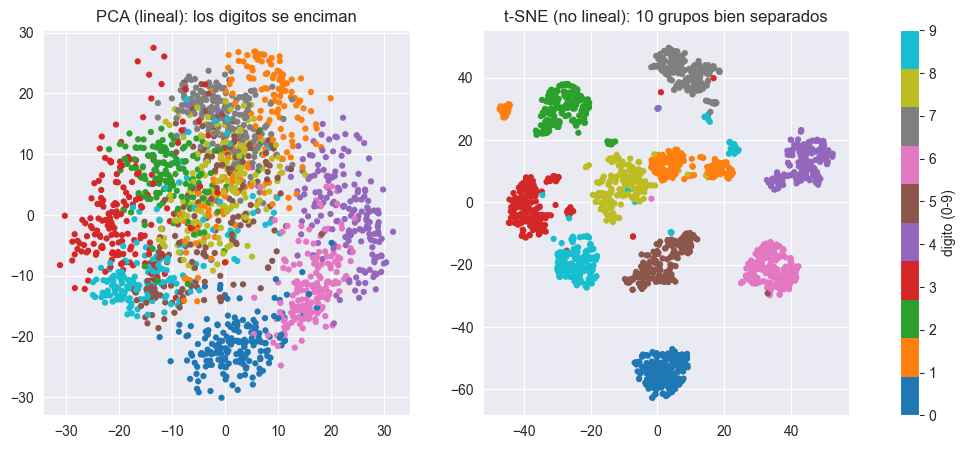

In [66]:
# ✨ Extra: PCA vs t-SNE sobre los MISMOS 64-D, lado a lado
Xd = digits.data
pca_d = PCA(n_components=2).fit_transform(Xd)
tsne_d = TSNE(n_components=2, random_state=42).fit_transform(Xd)   # tarda unos segundos

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
a1.scatter(pca_d[:, 0], pca_d[:, 1], c=digits.target, cmap='tab10', s=12)
a1.set_title('PCA (lineal): los digitos se enciman')
sc = a2.scatter(tsne_d[:, 0], tsne_d[:, 1], c=digits.target, cmap='tab10', s=12)
a2.set_title('t-SNE (no lineal): 10 grupos bien separados')
fig.colorbar(sc, ax=[a1, a2], label='digito (0-9)')
plt.show()

**Desglose — aquí se ve TODO:**

- **PCA** (lineal) encima varios dígitos: con solo 2 ejes rectos no alcanza para separar 10 clases en 64D.
- **t-SNE** (no lineal) separa los **10 dígitos en grupos limpios**. *Este* es su caso de uso estrella: **visualizar estructura en alta dimensión**.

✨ **Por eso en Iris no se notaba la diferencia:** 4 dimensiones es "demasiado fácil". El valor real de t-SNE aparece cuando hay muchas.

> ✅ **Qué demostramos:** t-SNE **separó los 10 dígitos (64D)** donde PCA los encimó — su fuerte es **ver** estructura no lineal en alta dimensión.

## 17. PCA vs t-SNE

| | **PCA** | **t-SNE** |
|---|---|---|
| Tipo | **Lineal** | **No lineal** |
| Preserva | Varianza **global** | **Vecindarios** locales |
| ¿`transform` a datos nuevos? | **Sí** | **No** |
| ¿Determinista? | Sí | **No** (fija `random_state`) |
| Distancias entre grupos | Significan algo | **No** confiar en ellas |
| Uso principal | Comprimir + acelerar + visualizar | **Solo visualizar** alta dimensión |

## 18. 🎯 Síntesis: ¿qué algoritmo cuándo?

```
¿Tu objetivo es...?
│
├─ AGRUPAR (clustering)
│    ├─ Sé cuántos grupos hay y son compactos ......... K-Means
│    ├─ Formas raras / hay ruido / no sé cuántos ...... DBSCAN
│    └─ Quiero ver la jerarquía y decidir K después ... Jerárquico (dendrograma)
│
└─ SIMPLIFICAR (reducción de dimensión)
     ├─ Comprimir / acelerar / datos nuevos ........... PCA
     └─ Solo visualizar estructura en alta dimensión .. t-SNE
```

**3 ideas para llevarse:**

1. **No supervisado = sin etiquetas:** el modelo descubre estructura solo (`X`, sin `y`).
2. **Mismo patrón para todo:** `Estimador(...).fit(X)` → `.labels_`/`.predict` (clustering) o `.transform` (reducción). Lo aprendido vive en los atributos con `_`.
3. **Evaluar es difícil:** no hay "accuracy". Validamos contra `species` solo porque Iris las traía — un lujo que casi nunca tendrás.

## 19. ✨ Resumen: qué agregamos nosotros al video

Para dejar clarísimo nuestro aporte (útil para la calificación 😉):

| 🎬 Tal cual del video | ✨ Extra que agregamos |
|---|---|
| K-Means (fit, centroides, inercia, codo) | Carga **offline** robusta del dataset |
| DBSCAN (fit, `labels_`, scatter) | "Anatomía del estimador sklearn" (hilo unificador) |
| PCA (fit/transform, scatter) | Validación con `crosstab` contra especies reales |
| t-SNE (fit_transform, scatter) | **Silueta** además del codo (y la lección de que discrepan) |
| Referencias del autor | Demo **two-moons** (K-Means falla / DBSCAN gana) |
| | **Dendrograma** jerárquico (el video lo deja sin resolver) |
| | **Varianza explicada + scree plot** de PCA |
| | `random_state` en t-SNE (reproducibilidad) |
| | Demo **digits 64-D** (PCA vs t-SNE) |
| | Tablas comparativas + guía de decisión |

## 20. Referencias 🎬

- Curso original: [*Machine Learning with Python and Scikit-Learn*](https://youtu.be/hDKCxebp88A) (freeCodeCamp / Jovian) — Lección 6.
- [scikit-learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [scikit-learn: Unsupervised learning](https://scikit-learn.org/stable/unsupervised_learning.html)
- [Visualizing clustering (con GIFs)](https://dashee87.github.io/data%20science/general/Clustering-with-Scikit-with-GIFs/)